In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import itertools
import seaborn_image as isns
import statsmodels.api as sm
import statsmodels.formula.api as smf
sns.set(font_scale=2) 
sns.set_style("ticks")

In [2]:
def preprocess_plot(df, name, plotting = True):
    ls = ['Cm(pF)', 'Firing_freq_(Hz)_I0','Instant_freq_(Hz)', 'isi_(ms)',  'CaT',  'Ih_at_-120mV', 'AP_ampl', 'AP_halfwidth', 'AP_time_to_peak','area(mV_ms)', 'rheobase_at_-60mV_(pA)', 'AHP_(mV)', 'Vm',
       'Input_Resistance', 'sPSC_frequency', 'sPSC_Amplitude(pA)','sPSCs_Rise time', 'sPSCs (decay)', 'AC-I0', 'AC_-60']

    for column in ls:
        _, p = stats.ttest_ind(df[(df.state == 'Pre')][column].dropna(),
                                    df[(df.state == 'Post')][column].dropna(),
                                    equal_var = False)
        print(column , p)
        
        if plotting:
            df[column] = pd.to_numeric(df[column])
            fig,ax = plt.subplots(figsize = (2,3))
            sns.swarmplot(x='state', y =column, data= df, palette = ['darkgray', '#F97306'], alpha = 1)
            sns.boxplot(x='state', y =column, data= df, palette = ['darkgray', '#F97306'], boxprops=dict(alpha=0.7), width = 0.5)
            sns.despine()
            plt.title(column + '_' + str(p)[:4], pad = 20)
            plt.savefig(f'output_figures/{name}_{column}.png',dpi = 300, bbox_inches = 'tight')
            plt.show()
            

def proportion(df, column1, column2, cols):
    prop = pd.crosstab(df[column1], df[column2], margins = True).reset_index()
    prop = prop.set_index(column1)
    prop = prop.iloc[:-1, :-1]
    stat, p, dof, expected  = stats.chi2_contingency(prop)
    print(p)
    
    prop = prop.apply(lambda x: x.div(x.sum()).mul(100), axis=1)
    
    
    prop = prop[cols]
    prop = prop.reset_index()
    return prop

def prop_plot(df, column):
    df.plot(x = column, 
              kind = 'bar', 
              stacked = True,  
              mark_right = False,
              color = ['black', 'darkgray','gray'],
              figsize = (3,5), alpha = 0.7)
    plt.xticks(rotation = 0)
    ax = plt.gca()
    plt.ylabel('Percentage (%)')
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)

In [3]:
df = pd.read_csv('ephys_analysis_MC.csv')
df.loc[df.Behaviour_6hFD =='no_FD','state'] = 'Pre'
df.loc[df.Behaviour_6hFD =='Agg+','state'] = 'Post'
df.rename(columns = {'Instant_freq_(Hz)_1/ISI':'Instant_freq_(Hz)'}, inplace =True)


gal = df[df.Gal_positive == 'yes']
no_gal = df[df.Gal_positive == 'no']
ephys = df[df.Gal_positive !='yes']
sample_num= ephys[ephys.Gal_positive== 'no'].shape[0]/4
ephys = pd.concat([ephys, gal.sample(int(sample_num))], axis = 0)

Cm(pF) 0.6388547052757143


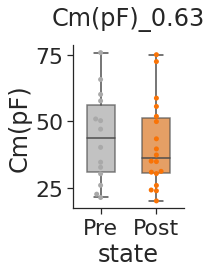

Firing_freq_(Hz)_I0 0.5235448116614392


/home/tochenan/.conda/envs/dlc-ubuntu-CPU/lib/python3.7/site-packages/seaborn/categorical.py:1296: UserWarning: 14.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


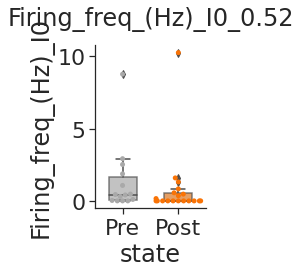

Instant_freq_(Hz) 0.3800692399940495


/home/tochenan/.conda/envs/dlc-ubuntu-CPU/lib/python3.7/site-packages/seaborn/categorical.py:1296: UserWarning: 9.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


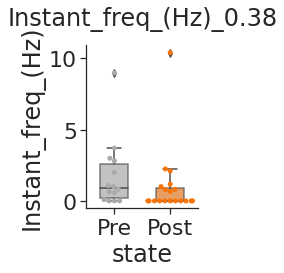

isi_(ms) 0.20637601059567065


/home/tochenan/.conda/envs/dlc-ubuntu-CPU/lib/python3.7/site-packages/seaborn/categorical.py:1296: UserWarning: 23.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


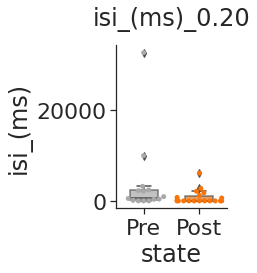

CaT 0.41972390622515254


/home/tochenan/.conda/envs/dlc-ubuntu-CPU/lib/python3.7/site-packages/seaborn/categorical.py:1296: UserWarning: 19.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


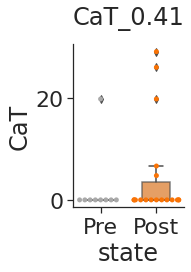

Ih_at_-120mV 0.13724023028924762


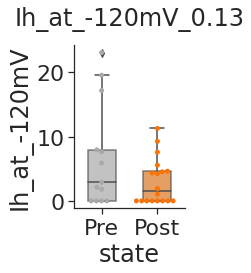

AP_ampl 0.0643880602433923


/home/tochenan/.conda/envs/dlc-ubuntu-CPU/lib/python3.7/site-packages/seaborn/categorical.py:1296: UserWarning: 9.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


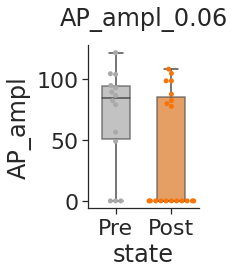

AP_halfwidth 0.17603488541284856


/home/tochenan/.conda/envs/dlc-ubuntu-CPU/lib/python3.7/site-packages/seaborn/categorical.py:1296: UserWarning: 9.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


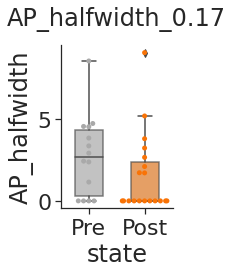

AP_time_to_peak 0.2243412266188597


/home/tochenan/.conda/envs/dlc-ubuntu-CPU/lib/python3.7/site-packages/seaborn/categorical.py:1296: UserWarning: 9.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


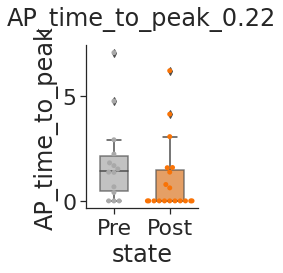

area(mV_ms) 0.13431324331402797


/home/tochenan/.conda/envs/dlc-ubuntu-CPU/lib/python3.7/site-packages/seaborn/categorical.py:1296: UserWarning: 9.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


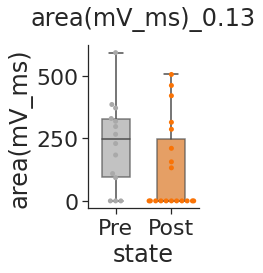

rheobase_at_-60mV_(pA) 0.6565853207451338


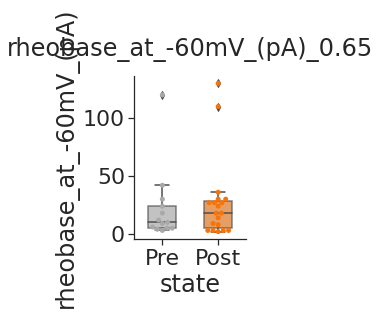

AHP_(mV) 0.03885192423201539


/home/tochenan/.conda/envs/dlc-ubuntu-CPU/lib/python3.7/site-packages/seaborn/categorical.py:1296: UserWarning: 9.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


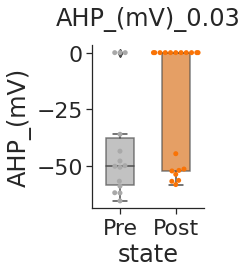

Vm 0.37936654308331796


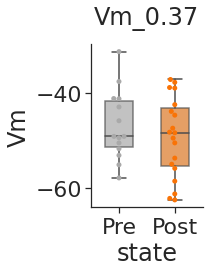

Input_Resistance 0.5405733020707282


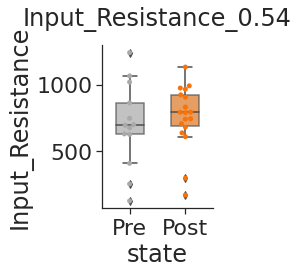

sPSC_frequency 0.730905658002079


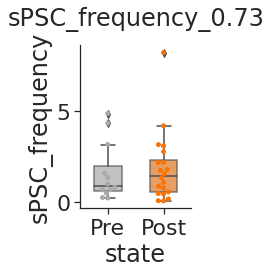

sPSC_Amplitude(pA) 0.8120670836579271


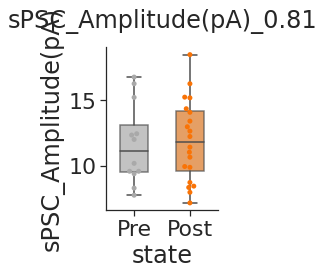

sPSCs_Rise time 0.6914032700275887


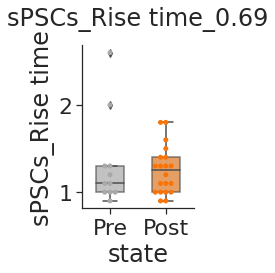

sPSCs (decay) 0.22046215602373836


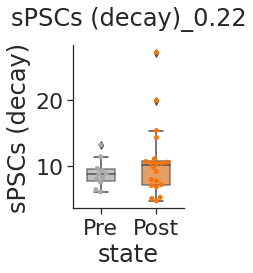

AC-I0 nan


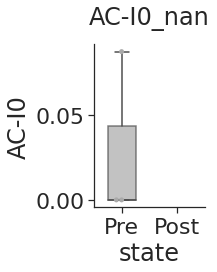

AC_-60 nan


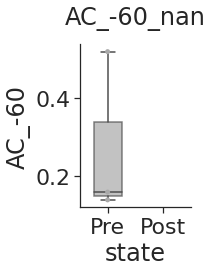

In [4]:
preprocess_plot(ephys, 'pan')

Cm(pF) 0.6884576131050248


/home/tochenan/.conda/envs/dlc-ubuntu-CPU/lib/python3.7/site-packages/ipykernel_launcher.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  if sys.path[0] == '':


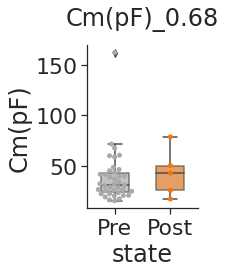

Firing_freq_(Hz)_I0 0.4438939031683873


/home/tochenan/.conda/envs/dlc-ubuntu-CPU/lib/python3.7/site-packages/ipykernel_launcher.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  if sys.path[0] == '':


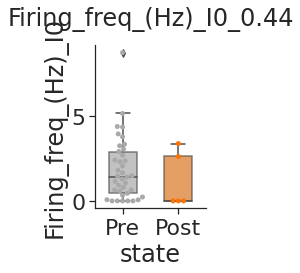

Instant_freq_(Hz) 0.34900567858902065


/home/tochenan/.conda/envs/dlc-ubuntu-CPU/lib/python3.7/site-packages/ipykernel_launcher.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  if sys.path[0] == '':


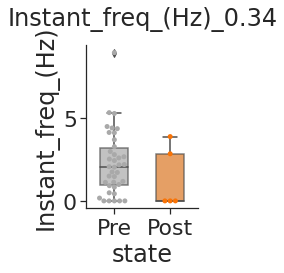

isi_(ms) 0.0181978385784736


/home/tochenan/.conda/envs/dlc-ubuntu-CPU/lib/python3.7/site-packages/ipykernel_launcher.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  if sys.path[0] == '':
/home/tochenan/.conda/envs/dlc-ubuntu-CPU/lib/python3.7/site-packages/seaborn/categorical.py:1296: UserWarning: 28.9% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


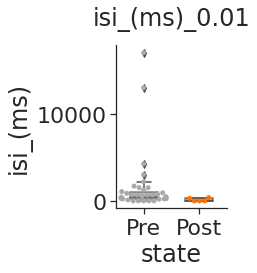

CaT 0.00035058912426213156


/home/tochenan/.conda/envs/dlc-ubuntu-CPU/lib/python3.7/site-packages/ipykernel_launcher.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  if sys.path[0] == '':
/home/tochenan/.conda/envs/dlc-ubuntu-CPU/lib/python3.7/site-packages/seaborn/categorical.py:1296: UserWarning: 31.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


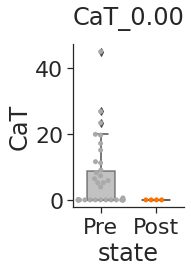

Ih_at_-120mV 0.6907686227594474


/home/tochenan/.conda/envs/dlc-ubuntu-CPU/lib/python3.7/site-packages/ipykernel_launcher.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  if sys.path[0] == '':


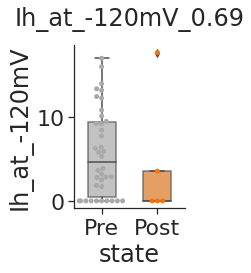

AP_ampl 0.07584325128554945


/home/tochenan/.conda/envs/dlc-ubuntu-CPU/lib/python3.7/site-packages/ipykernel_launcher.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  if sys.path[0] == '':


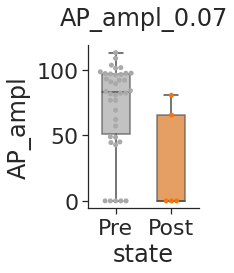

AP_halfwidth 0.04618348412219337


/home/tochenan/.conda/envs/dlc-ubuntu-CPU/lib/python3.7/site-packages/ipykernel_launcher.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  if sys.path[0] == '':
/home/tochenan/.conda/envs/dlc-ubuntu-CPU/lib/python3.7/site-packages/seaborn/categorical.py:1296: UserWarning: 5.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


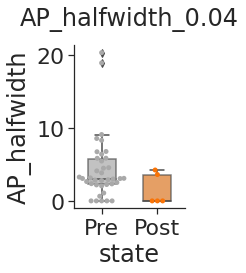

/home/tochenan/.conda/envs/dlc-ubuntu-CPU/lib/python3.7/site-packages/ipykernel_launcher.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  if sys.path[0] == '':


AP_time_to_peak 0.0006686491512994912


/home/tochenan/.conda/envs/dlc-ubuntu-CPU/lib/python3.7/site-packages/seaborn/categorical.py:1296: UserWarning: 5.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


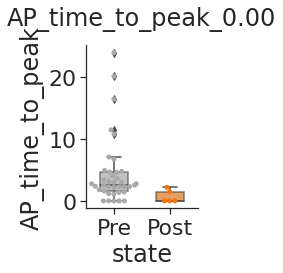

/home/tochenan/.conda/envs/dlc-ubuntu-CPU/lib/python3.7/site-packages/ipykernel_launcher.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  if sys.path[0] == '':


area(mV_ms) 0.0049283876235511


/home/tochenan/.conda/envs/dlc-ubuntu-CPU/lib/python3.7/site-packages/seaborn/categorical.py:1296: UserWarning: 5.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


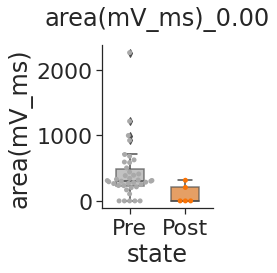

rheobase_at_-60mV_(pA) 0.20269557210787412


/home/tochenan/.conda/envs/dlc-ubuntu-CPU/lib/python3.7/site-packages/ipykernel_launcher.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  if sys.path[0] == '':


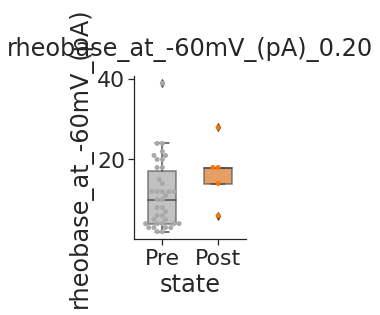

AHP_(mV) 0.08177463343806074


/home/tochenan/.conda/envs/dlc-ubuntu-CPU/lib/python3.7/site-packages/ipykernel_launcher.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  if sys.path[0] == '':


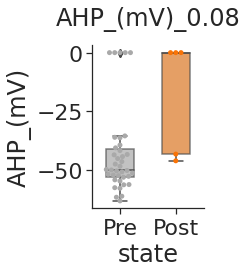

Vm 0.7258126898330631


/home/tochenan/.conda/envs/dlc-ubuntu-CPU/lib/python3.7/site-packages/ipykernel_launcher.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  if sys.path[0] == '':


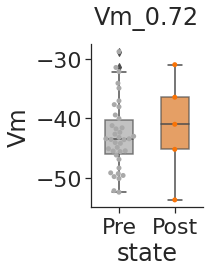

Input_Resistance 0.8374107246484368


/home/tochenan/.conda/envs/dlc-ubuntu-CPU/lib/python3.7/site-packages/ipykernel_launcher.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  if sys.path[0] == '':


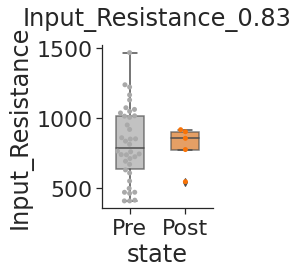

sPSC_frequency 0.174787166175601


/home/tochenan/.conda/envs/dlc-ubuntu-CPU/lib/python3.7/site-packages/ipykernel_launcher.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  if sys.path[0] == '':


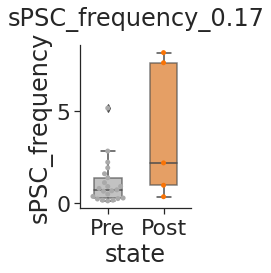

sPSC_Amplitude(pA) 0.38409799383528087


/home/tochenan/.conda/envs/dlc-ubuntu-CPU/lib/python3.7/site-packages/ipykernel_launcher.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  if sys.path[0] == '':


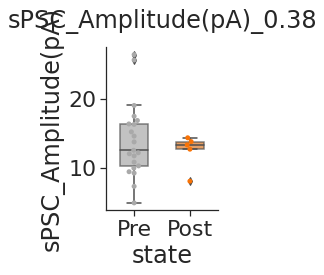

sPSCs_Rise time nan


/home/tochenan/.conda/envs/dlc-ubuntu-CPU/lib/python3.7/site-packages/ipykernel_launcher.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  if sys.path[0] == '':


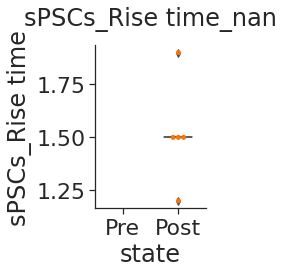

sPSCs (decay) nan


/home/tochenan/.conda/envs/dlc-ubuntu-CPU/lib/python3.7/site-packages/ipykernel_launcher.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  if sys.path[0] == '':


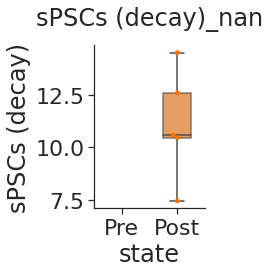

AC-I0 nan


/home/tochenan/.conda/envs/dlc-ubuntu-CPU/lib/python3.7/site-packages/ipykernel_launcher.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  if sys.path[0] == '':
/home/tochenan/.conda/envs/dlc-ubuntu-CPU/lib/python3.7/site-packages/seaborn/categorical.py:1296: UserWarning: 57.9% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


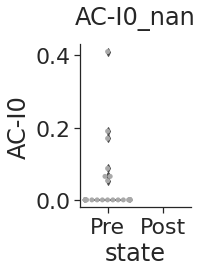

AC_-60 nan


/home/tochenan/.conda/envs/dlc-ubuntu-CPU/lib/python3.7/site-packages/ipykernel_launcher.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  if sys.path[0] == '':
/home/tochenan/.conda/envs/dlc-ubuntu-CPU/lib/python3.7/site-packages/seaborn/categorical.py:1296: UserWarning: 23.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


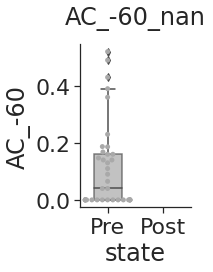

In [51]:
preprocess_plot(gal,'gal')

Cm(pF) 0.8500640059886866


/home/tochenan/.conda/envs/dlc-ubuntu-CPU/lib/python3.7/site-packages/ipykernel_launcher.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  if sys.path[0] == '':


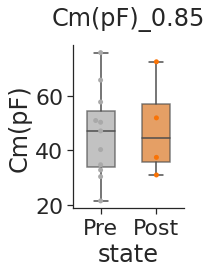

Firing_freq_(Hz)_I0 0.49217385624488574


/home/tochenan/.conda/envs/dlc-ubuntu-CPU/lib/python3.7/site-packages/ipykernel_launcher.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  if sys.path[0] == '':


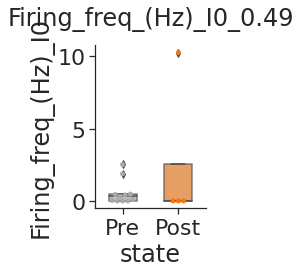

Instant_freq_(Hz) 0.5434242187065756


/home/tochenan/.conda/envs/dlc-ubuntu-CPU/lib/python3.7/site-packages/ipykernel_launcher.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  if sys.path[0] == '':


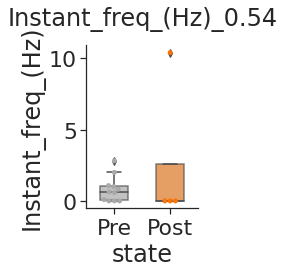

isi_(ms) 0.12701251180667658


/home/tochenan/.conda/envs/dlc-ubuntu-CPU/lib/python3.7/site-packages/ipykernel_launcher.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  if sys.path[0] == '':


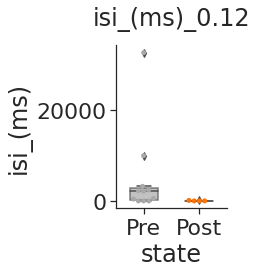

CaT 0.31129113670632236


/home/tochenan/.conda/envs/dlc-ubuntu-CPU/lib/python3.7/site-packages/ipykernel_launcher.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  if sys.path[0] == '':


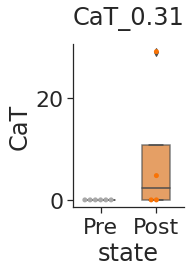

Ih_at_-120mV 0.15155282630883343


/home/tochenan/.conda/envs/dlc-ubuntu-CPU/lib/python3.7/site-packages/ipykernel_launcher.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  if sys.path[0] == '':


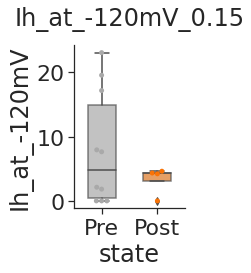

AP_ampl 0.19447527695601594


/home/tochenan/.conda/envs/dlc-ubuntu-CPU/lib/python3.7/site-packages/ipykernel_launcher.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  if sys.path[0] == '':


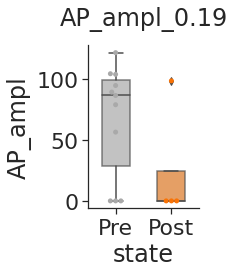

AP_halfwidth 0.05002522660652634


/home/tochenan/.conda/envs/dlc-ubuntu-CPU/lib/python3.7/site-packages/ipykernel_launcher.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  if sys.path[0] == '':


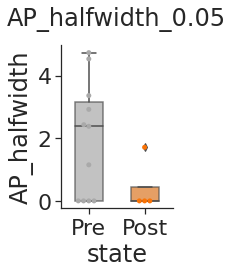

AP_time_to_peak 0.011796076323618091


/home/tochenan/.conda/envs/dlc-ubuntu-CPU/lib/python3.7/site-packages/ipykernel_launcher.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  if sys.path[0] == '':


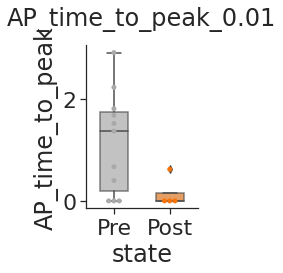

area(mV_ms) 0.024475362608384257


/home/tochenan/.conda/envs/dlc-ubuntu-CPU/lib/python3.7/site-packages/ipykernel_launcher.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  if sys.path[0] == '':


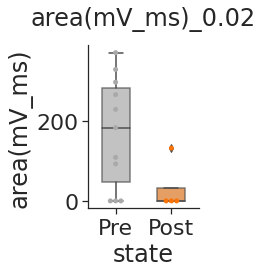

rheobase_at_-60mV_(pA) 0.6591097277932811


/home/tochenan/.conda/envs/dlc-ubuntu-CPU/lib/python3.7/site-packages/ipykernel_launcher.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  if sys.path[0] == '':


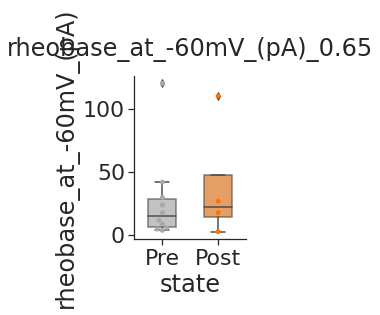

AHP_(mV) 0.13310979829949734


/home/tochenan/.conda/envs/dlc-ubuntu-CPU/lib/python3.7/site-packages/ipykernel_launcher.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  if sys.path[0] == '':


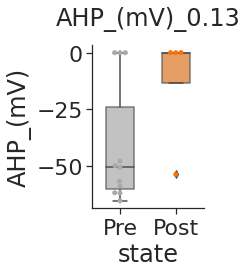

Vm 0.11810699275074775


/home/tochenan/.conda/envs/dlc-ubuntu-CPU/lib/python3.7/site-packages/ipykernel_launcher.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  if sys.path[0] == '':


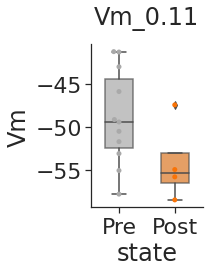

Input_Resistance 0.7049826289776826


/home/tochenan/.conda/envs/dlc-ubuntu-CPU/lib/python3.7/site-packages/ipykernel_launcher.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  if sys.path[0] == '':


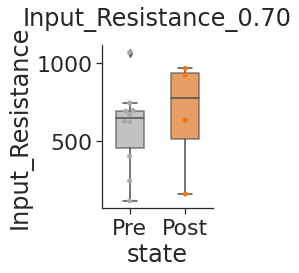

sPSC_frequency 0.9883561191278416


/home/tochenan/.conda/envs/dlc-ubuntu-CPU/lib/python3.7/site-packages/ipykernel_launcher.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  if sys.path[0] == '':


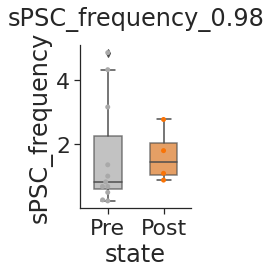

sPSC_Amplitude(pA) 0.7600631314064364


/home/tochenan/.conda/envs/dlc-ubuntu-CPU/lib/python3.7/site-packages/ipykernel_launcher.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  if sys.path[0] == '':


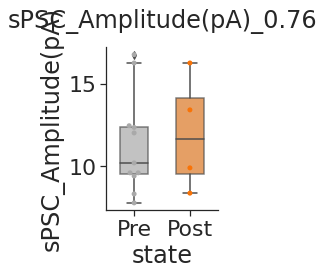

sPSCs_Rise time 0.8214960880584362


/home/tochenan/.conda/envs/dlc-ubuntu-CPU/lib/python3.7/site-packages/ipykernel_launcher.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  if sys.path[0] == '':


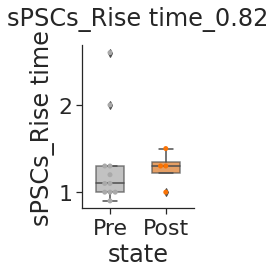

sPSCs (decay) 0.9949427406790006


/home/tochenan/.conda/envs/dlc-ubuntu-CPU/lib/python3.7/site-packages/ipykernel_launcher.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  if sys.path[0] == '':


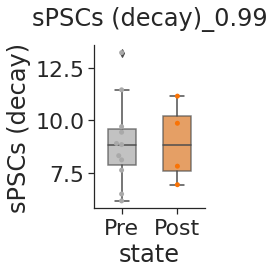

AC-I0 nan


/home/tochenan/.conda/envs/dlc-ubuntu-CPU/lib/python3.7/site-packages/ipykernel_launcher.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  if sys.path[0] == '':


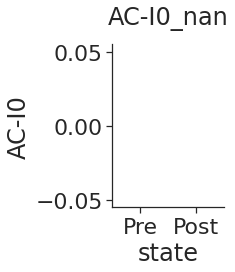

AC_-60 nan


/home/tochenan/.conda/envs/dlc-ubuntu-CPU/lib/python3.7/site-packages/ipykernel_launcher.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  if sys.path[0] == '':


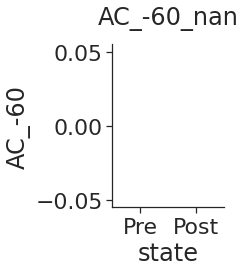

In [52]:
preprocess_plot(no_gal,'gal_minus')

Cm(pF) 0.7323693240149414


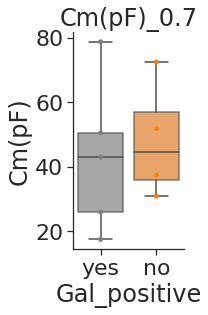

Firing_freq_(Hz)_I0 0.6407646405225094


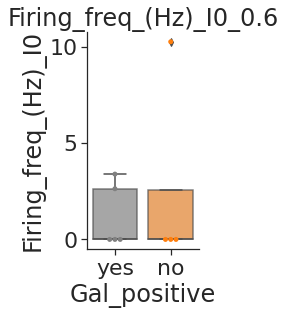

Instant_freq_(Hz) 0.6729139443059836


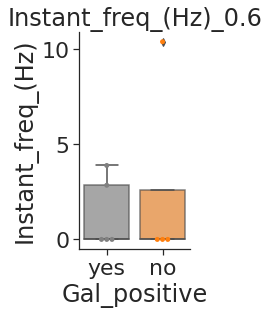

isi_(ms) 0.264690461240659


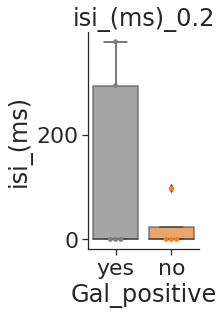

CaT 0.31129113670632236


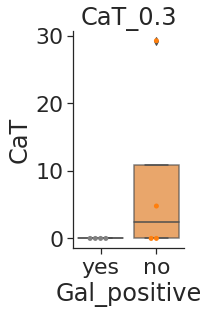

Ih_at_-120mV 0.8027274535869497


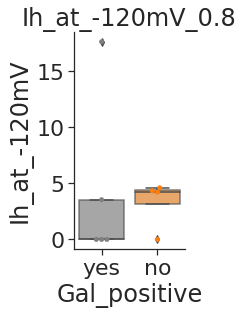

AP_ampl 0.8859255231987084


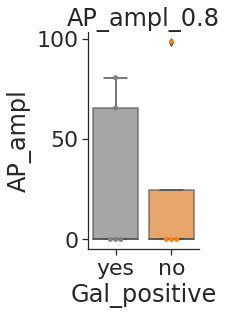

AP_halfwidth 0.32548590700011526


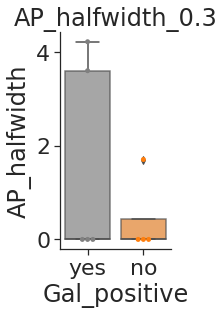

AP_time_to_peak 0.2899382771639767


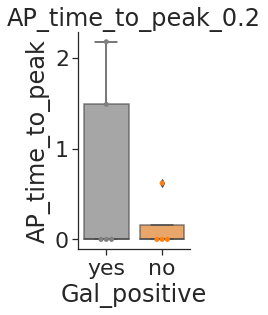

area(mV_ms) 0.37498685458791303


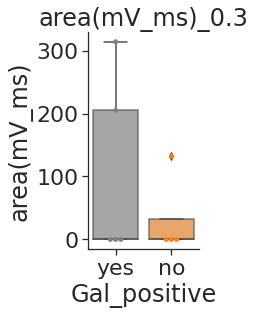

rheobase_at_-60mV_(pA) 0.4161053280322605


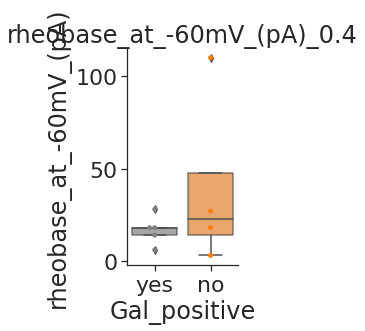

AHP_(mV) 0.80731274924489


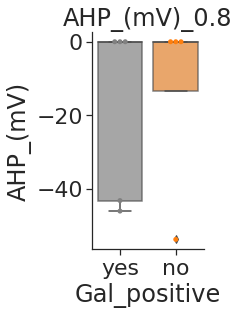

Vm 0.029015379282701693


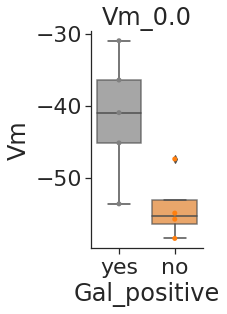

Input_Resistance 0.5478892229399516


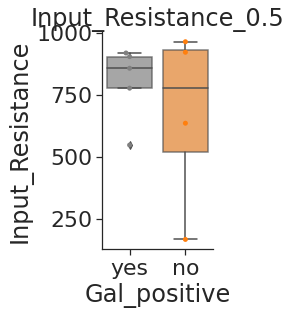

sPSC_frequency 0.2622481192613918


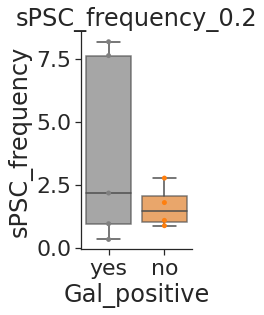

sPSC_Amplitude(pA) 0.8336416545013177


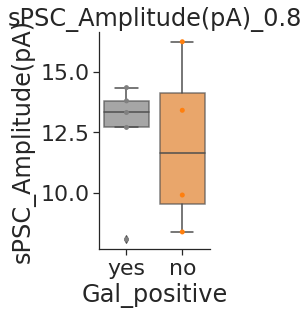

sPSCs_Rise time 0.1506195618276334


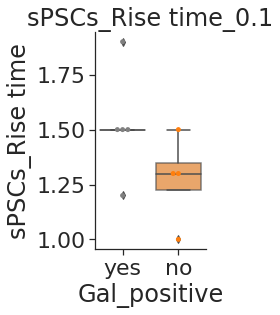

sPSCs (decay) 0.1946103198988769


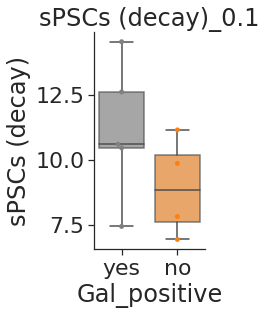

AC-I0 nan


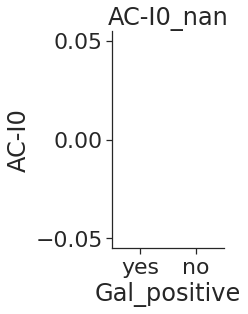

AC_-60 nan


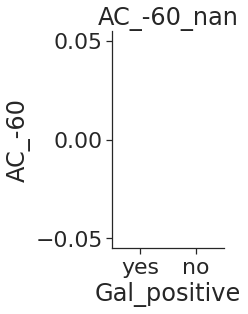

In [53]:
gals = pd.concat([gal,no_gal], axis = 0)
gals = gals[gals.state == 'Post']

ls = ['Cm(pF)', 'Firing_freq_(Hz)_I0','Instant_freq_(Hz)', 'isi_(ms)',  'CaT',  'Ih_at_-120mV', 'AP_ampl', 'AP_halfwidth', 'AP_time_to_peak','area(mV_ms)', 'rheobase_at_-60mV_(pA)', 'AHP_(mV)', 'Vm',
   'Input_Resistance', 'sPSC_frequency', 'sPSC_Amplitude(pA)','sPSCs_Rise time', 'sPSCs (decay)', 'AC-I0', 'AC_-60']

for column in ls:
    _, p = stats.ttest_ind(gals[(gals.Gal_positive == 'yes')][column].dropna(),
                                gals[(gals.Gal_positive == 'no')][column].dropna(),
                                equal_var = False)
    print(column , p)


    gals[column] = pd.to_numeric(gals[column])
    fig,ax = plt.subplots(figsize = (2,4))
    sns.swarmplot(x='Gal_positive', y =column, data= gals, palette = ['gray', 'Tab:orange'])
    sns.boxplot(x='Gal_positive', y =column, data= gals, palette = ['gray', 'Tab:orange'], boxprops=dict(alpha=0.7))
    sns.despine()
    plt.title(column + '_' + str(p)[:3])
    plt.savefig(f'output_figures/gal_nogal_{column}.png',dpi = 300, bbox_inches = 'tight')
    plt.show()

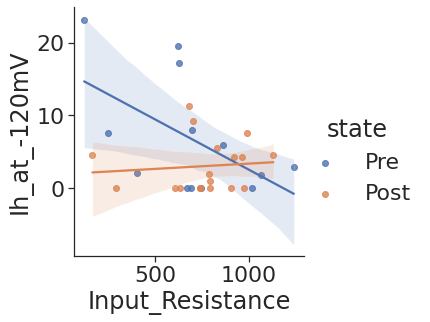

In [11]:
sns.lmplot(x = 'Input_Resistance',
            y = 'Ih_at_-120mV',
           hue = 'state',
            data = ephys)
sns.despine()

0.0850436211106937


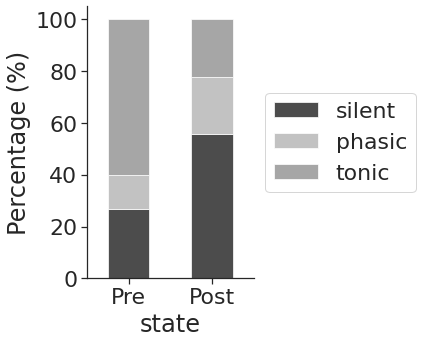

In [126]:
## silent proportion
cols = ['silent', 'phasic', 'tonic']
silent_prop = proportion(ephys, 'state', 'I_zero', cols)
silent_prop['state'] = pd.Categorical(silent_prop['state'], ['Pre', 'Post'])
silent_prop = silent_prop.sort_values(by = ['state'])
prop_plot(silent_prop, 'state')
plt.savefig('output_figures/silent_prop.png',dpi = 300, bbox_inches = 'tight')

0.8125242693153686


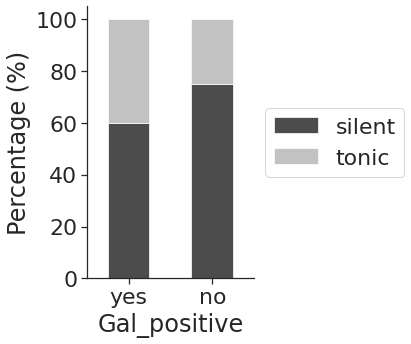

In [119]:
cols = ['silent', 'tonic']
silent_prop = proportion(gals, 'Gal_positive', 'I_zero', cols)
silent_prop['Gal_positive'] = pd.Categorical(silent_prop['Gal_positive'], ['yes', 'no'])
silent_prop = silent_prop.sort_values(by = ['Gal_positive'])
prop_plot(silent_prop, 'Gal_positive')
plt.savefig('output_figures/galanin_silent_prop.png',dpi = 300, bbox_inches = 'tight')

0.8728892053762423


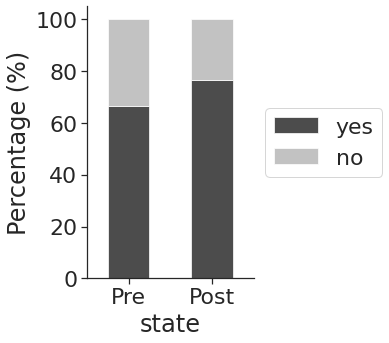

In [120]:
## adaptive proportion
cols = ['yes', 'no']
ad_prop = proportion(ephys, 'state', 'Adaptive', cols)
ad_prop['state'] = pd.Categorical(ad_prop['state'], ['Pre', 'Post'])
ad_prop = ad_prop.sort_values(by = ['state'])
prop_plot(ad_prop, 'state')
plt.savefig('output_figures/adaptive_prop.png',dpi = 300, bbox_inches = 'tight')

0.7076604666545525


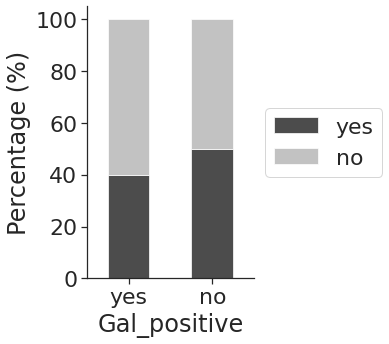

In [121]:
cols = ['yes', 'no']
ad_prop = proportion(gals, 'Gal_positive', 'Adaptive', cols)
ad_prop['Gal_positive'] = pd.Categorical(ad_prop['Gal_positive'], ['yes', 'no'])
ad_prop = ad_prop.sort_values(by = ['Gal_positive'])
prop_plot(ad_prop, 'Gal_positive')
plt.savefig('output_figures/galanin_adaptive_prop.png',dpi = 300, bbox_inches = 'tight')

0.9315559017030229


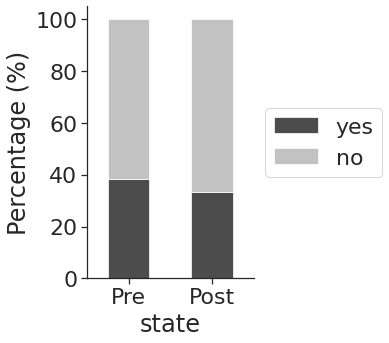

In [55]:
## calcium T proportion
cols = ['yes', 'no']
ca_prop = proportion(ephys, 'state', 'cat_categ', cols)
ca_prop['state'] = pd.Categorical(ca_prop['state'], ['Pre', 'Post'])
ca_prop = ca_prop.sort_values(by = ['state'])
prop_plot(ca_prop, 'state')
plt.savefig('output_figures/CaT_prop.png',dpi = 300, bbox_inches = 'tight')

0.8125242693153686


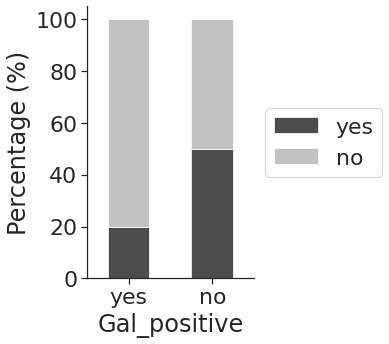

In [56]:
cols = ['yes', 'no']
ca_prop = proportion(gals, 'Gal_positive', 'cat_categ', cols)
ca_prop['Gal_positive'] = pd.Categorical(ca_prop['Gal_positive'], ['yes', 'no'])
ca_prop = ca_prop.sort_values(by = ['Gal_positive'])
prop_plot(ca_prop, 'Gal_positive')
plt.savefig('output_figures/galanin_CaT_prop.png',dpi = 300, bbox_inches = 'tight')